# 03. Evasion Analysis

        This notebook demonstrates the **robustness and evasion phase** of the project.

        The main question is no longer "what circuit exists?" but:
        - what happens to that circuit under conservative, runnable obfuscation?

        In mechanistic terms:
        - Does obfuscation remove the validated route?
        - Or does the model still represent the malicious evidence internally, while changing how it uses that evidence downstream?

        In plain language:
        - Is the model actually fooled because it stops seeing the danger?
        - Or does it still "notice" the danger, but fail to rely on it by the end?


In [1]:
from pathlib import Path
import math
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)


def read_csv(name: str) -> pd.DataFrame:
    path = ARTIFACTS / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_barh(df, label_col, value_col, *, title, xlabel, color="#2B6CB0", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(plot_df))))
    ax.barh(plot_df[label_col], plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    return fig, ax


Project root: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit
Artifacts dir: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit/artifacts


## Step 1: Load the evasion benchmark artifacts

        We use:
        - the expanded technique-level benchmark summary
        - late-carrier patching on the strongest evasion slice
        - slice-specific residual and tracing summaries for the final downstream analysis


In [2]:
benchmark = read_csv("evasion_candidate_benchmark_summary_v2.csv")
patch_variant = read_csv("evasion_path_patching_late_invoke_webrequest_variant_v2_h100_summary.csv")
trace_variant = read_csv("evasion_trace_resid_pre13_mean_delta_l12_invoke_webrequest_variant_v2_h100_summary.csv")
resid_pre31_variant = read_csv("evasion_resid_pre31_mean_delta_ablate_l12_top4_invoke_webrequest_variant_v2_h100_summary.csv")

benchmark


,technique_id,variant_count,evasion_success_rate,classification_change_rate,mean_variant_logit_diff,mean_logit_delta_vs_seed
0,invoke_webrequest_alias,4,1.000000,1.000000,-0.296875,-0.453125
1,downloadstring_psobject_invoke,6,0.333333,0.333333,0.940104,-1.135417
2,downloadfile_psobject_invoke,4,0.000000,0.000000,5.199219,-1.683594
3,start_process_call_operator_string,4,0.000000,0.000000,6.574219,-0.308594
4,invoke_expression_scriptblock_create,4,0.000000,0.000000,0.015625,-0.109375
5,invoke_webrequest_call_operator_string,4,0.000000,0.000000,0.234375,0.078125
6,invoke_expression_call_operator_string,4,0.000000,0.000000,0.375000,0.250000
7,iex_scriptblock_create,6,0.000000,0.000000,4.195312,0.791667
8,iex_call_operator_string,6,0.000000,0.000000,4.658854,1.255208


## Step 2: Which evasion techniques actually work?

        A useful evasion benchmark should not treat every string rewrite as equally meaningful.
        Here, the important outcome is whether a conservative, syntax-preserving transform actually flips the model from `BLOCK` to `ALLOW`.


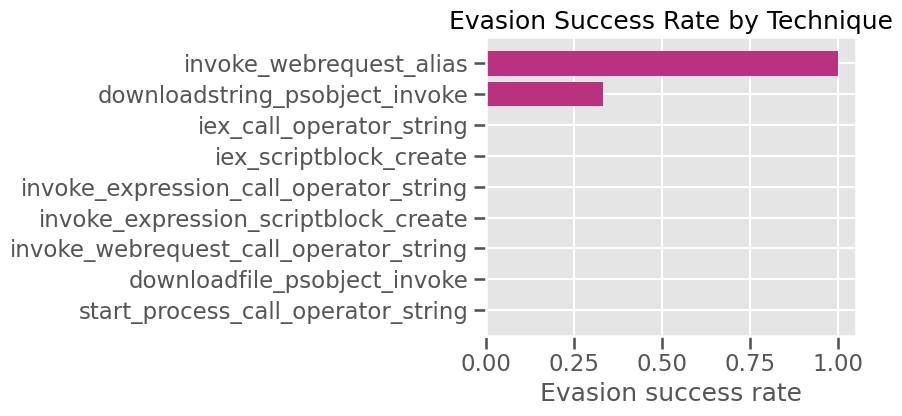

,technique_id,variant_count,evasion_success_rate,classification_change_rate,mean_variant_logit_diff,mean_logit_delta_vs_seed
0,invoke_webrequest_alias,4,1.000000,1.000000,-0.296875,-0.453125
1,downloadstring_psobject_invoke,6,0.333333,0.333333,0.940104,-1.135417
2,downloadfile_psobject_invoke,4,0.000000,0.000000,5.199219,-1.683594
3,start_process_call_operator_string,4,0.000000,0.000000,6.574219,-0.308594
4,invoke_expression_scriptblock_create,4,0.000000,0.000000,0.015625,-0.109375
5,invoke_webrequest_call_operator_string,4,0.000000,0.000000,0.234375,0.078125
6,invoke_expression_call_operator_string,4,0.000000,0.000000,0.375000,0.250000
7,iex_scriptblock_create,6,0.000000,0.000000,4.195312,0.791667
8,iex_call_operator_string,6,0.000000,0.000000,4.658854,1.255208


In [3]:
plot_df = benchmark.sort_values("evasion_success_rate", ascending=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_df["technique_id"], plot_df["evasion_success_rate"], color="#B83280")
ax.set_title("Evasion Success Rate by Technique")
ax.set_xlabel("Evasion success rate")
plt.tight_layout()
plt.show()

benchmark.sort_values("evasion_success_rate", ascending=False)


## Step 3: The first key surprise

        On the strongest failure mode, `invoke_webrequest_alias`, the validated late carrier is still **sufficient**.

        That means:
        - if we patch the old late bundle back in, we can still push the model toward the malicious decision

        In plain language:
        - the model still knows how to use the old signal if we force it to
        - but in the naturally evaded script, it is no longer relying on that signal in the same way


In [4]:
patch_variant


,patch_label,pair_count,mean_delta,max_delta,min_delta,flip_rate,mean_base_logit_diff
0,h12.15+h12.5+h12.4+h12.28,4,-1.117188,-0.59375,-1.59375,1.0,-0.296875


## Step 4: Trace the late writer family on the evaded variants

        The next question is whether the late carrier disappeared.

        To test that, we trace which `Layer 12` heads write most strongly into the slice-specific `resid_pre13` malicious-vs-benign direction for the evaded variants.


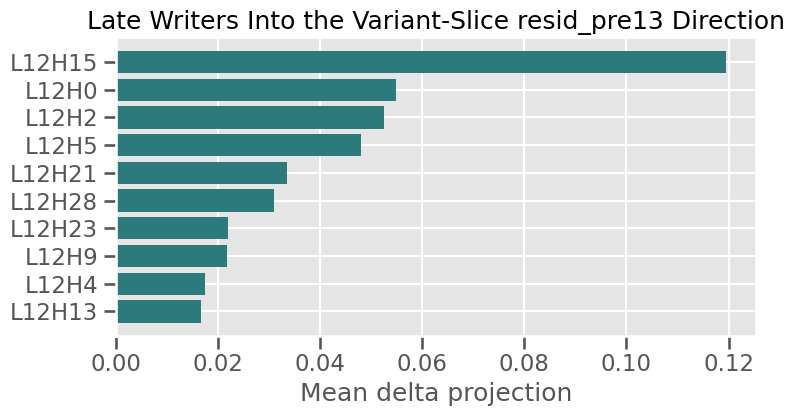

,head_label,mean_delta_projection,positive_delta_frac
0,L12H15,0.119401,1.0
1,L12H0,0.054899,1.0
2,L12H2,0.052547,1.0
3,L12H5,0.048054,1.0
4,L12H21,0.033493,1.0
5,L12H28,0.030941,1.0
6,L12H23,0.021933,1.0
7,L12H9,0.021759,1.0
8,L12H4,0.017563,1.0
9,L12H13,0.016745,1.0


In [5]:
top_trace = trace_variant.head(10).copy()
top_trace["head_label"] = top_trace.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)

show_barh(
    top_trace,
    "head_label",
    "mean_delta_projection",
    title="Late Writers Into the Variant-Slice resid_pre13 Direction",
    xlabel="Mean delta projection",
    color="#2C7A7B",
    sort=True,
)
plt.show()

top_trace[["head_label", "mean_delta_projection", "positive_delta_frac"]]


### Interpretation

        The usual late writer family does **not** disappear.

        The familiar heads are still there:
        - `L12H15` remains dominant
        - `H5`, `H2`, and `H28` remain in the main positive writer set

        So the evasion is **not** well described as "the model no longer carries the malicious evidence."


## Step 5: The final downstream probe

        The strongest final test asks where the sign split shows up.

        Earlier in the late stage, at `resid_pre13`, the late bundle still writes the familiar malicious-evidence direction even on evaded variants.

        Later, at `resid_pre31`, we test whether ablating the same late bundle still moves the late residual in the same direction.


In [6]:
resid_pre31_variant


,intervention_label,pair_count,mean_base_logit_diff,mean_intervened_logit_diff,mean_logit_delta,flip_rate,mean_base_projection,mean_intervened_projection,mean_projection_delta,positive_projection_delta_frac
0,ablate_h12.15+h12.5+h12.4+h12.28,4,-0.296875,0.046875,0.34375,0.0,11.039062,11.382812,0.34375,1.0


## Final interpretation

        This is the core robustness result:

        - the validated late carrier survives the evasion at `resid_pre13`
        - but later blocks transform or compensate for that evidence differently
        - by `resid_pre31`, the anti-causal split is already visible in the residual stream itself

        In plain language:
        - the model still contains the danger signal
        - but later computation has changed how much the final answer depends on that signal

        That is stronger and more precise than saying the circuit was simply "broken."


## Optional: Rerun notes

        These commands are GPU-friendly rather than CPU-friendly in practice, but they document the exact downstream probe used in the final writeup.


In [7]:
# Example only. Uncomment to rerun the final downstream probe.
#
# !python ../scaled_validation.py batch-residual-direction-intervention \
#     --manifest ../artifacts/evasion_pair_manifest_invoke_webrequest_variant_v2.csv \
#     --basis-path ../artifacts/evasion_invoke_webrequest_variant_v2_resid_pre31_contrastive_h100_basis.pt \
#     --basis-label mean_delta \
#     --heads 12.15,12.5,12.4,12.28 \
#     --mode ablate \
#     --device cuda \
#     --torch-dtype float16 \
#     --num-pairs 4 \
#     --allow-zero-indicator-malicious \
#     --output-prefix ../artifacts/demo_evasion_probe
